In [2]:
import numpy as np
import matplotlib.pyplot as plt

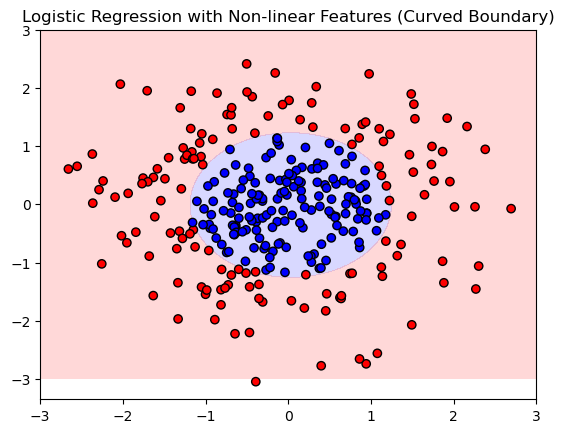

In [14]:
# --- Step 1: Generate circular dataset ---
np.random.seed(0)
N = 300
X = np.random.randn(N, 2)
y = (X[:,0]**2 + X[:,1]**2 > 1.5).astype(int)  # inside circle = 0, outside = 1

# --- Step 2: Add non-linear features ---
X_poly = np.c_[X, X[:,0]**2, X[:,1]**2]

# --- Sigmoid function ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# --- Step 3: Train logistic regression (from scratch) ---
w = np.zeros(X_poly.shape[1])
b = 0.0
lr = 0.1
epochs = 2000

for epoch in range(epochs):
    z = np.dot(X_poly, w) + b
    y_hat = sigmoid(z)
    dw = np.dot(X_poly.T, (y_hat - y)) / len(y)
    db = np.sum(y_hat - y) / len(y)
    w -= lr * dw
    b -= lr * db

# --- Step 4: Plot decision boundary ---
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid = np.c_[xx.ravel(), yy.ravel(), xx.ravel()**2, yy.ravel()**2]
probs = sigmoid(np.dot(grid, w) + b).reshape(xx.shape)

plt.contourf(xx, yy, probs, levels=[0,0.5,1], cmap="bwr", alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr", edgecolors="k")
plt.title("Logistic Regression with Non-linear Features (Curved Boundary)")
plt.show()
